In [1]:
from dotenv import load_dotenv
_ = load_dotenv()

In [2]:
!pip install langgraph langchain-openai langchain-community tavily-python

In [3]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults

C:\Users\johnb\AppData\Local\Temp\ipykernel_17548\2233616850.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [4]:
import os
from getpass import getpass

os.environ["TAVILY_API_KEY"] = getpass("Enter your Tavily API key: ")

Enter your Tavily API key:  ········


In [5]:
tool = TavilySearchResults(max_results=4) #increased number of results
print(type(tool))
print(tool.name)

<class 'langchain_community.tools.tavily_search.tool.TavilySearchResults'>
tavily_search_results_json


C:\Users\johnb\AppData\Local\Temp\ipykernel_17548\144666821.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=4) #increased number of results


In [6]:
!pip install -U langchain-tavily

In [7]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=4)

In [8]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [9]:
class Agent:

    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_openai)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_openai(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            if not t['name'] in self.tools:      # check for bad tool name from LLM
                print("\n ....bad tool name....")
                result = "bad tool name, retry"  # instruct LLM to retry if bad
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

In [10]:
import os
from getpass import getpass

os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

Enter your OpenAI API key:  ········


In [11]:
import os
from getpass import getpass

key = getpass("Enter OpenAI API key: ")

os.environ["OPENAI_API_KEY"] = key

print("Key stored successfully!")

Enter OpenAI API key:  ········


Key stored successfully!


In [12]:
prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""

model = ChatOpenAI(model="gpt-3.5-turbo")  #reduce inference cost
abot = Agent(model, [tool], system=prompt)

In [13]:
print("OPENAI_API_KEY" in os.environ)

True


In [14]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model="gpt-3.5-turbo")

In [15]:
!pip install pygraphviz

  Using cached pygraphviz-1.14.tar.gz (106 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build pygraphviz


  error: subprocess-exited-with-error
  
  exit code: 1
  
  [88 lines of output]
  C:\Users\johnb\AppData\Local\Temp\pip-build-env-et0jp4nl\overlay\Lib\site-packages\setuptools\config\_apply_pyprojecttoml.py:82: SetuptoolsDeprecationWarning: `project.license` as a TOML table is deprecated
  !!
  
          ********************************************************************************
          Please use a simple string containing a SPDX expression for `project.license`. You can also use `project.license-files`. (Both options available on setuptools>=77.0.0).
  
          By 2027-Feb-18, you need to update your project and remove deprecated calls
          or your builds will no longer be supported.
  
          See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
          ********************************************************************************
  
  !!
    corresp(dist, value, root_dir)
  C:\Users\johnb\AppData\Local\Temp\pip-build-

In [16]:
!pip install graphviz

In [17]:
import os

print("TAVILY_API_KEY" in os.environ)
print(os.environ.get("TAVILY_API_KEY", "")[:8])

True
tvly-dev


In [19]:
tool = TavilySearchResults(max_results=4)

In [20]:
messages = [HumanMessage(content="What is the weather in sf?")]

result = abot.graph.invoke({"messages": messages})

result["messages"][-1].content

Calling: {'name': 'tavily_search', 'args': {'query': 'current weather in San Francisco'}, 'id': 'call_VuIwYRg7xvCJGa2YPLKDnwN7', 'type': 'tool_call'}
Back to the model!


'The current weather in San Francisco is partly cloudy with a temperature of 55°F. The wind is blowing from the east-southeast at 8.3 km/h with 80% humidity.'

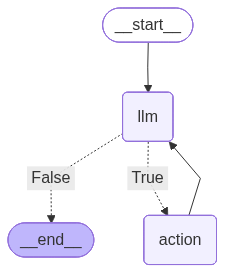

In [21]:
from IPython.display import Image

Image(abot.graph.get_graph().draw_mermaid_png())

In [22]:
messages = [HumanMessage(content="What is the weather in sf?")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search', 'args': {'query': 'weather in San Francisco', 'search_depth': 'fast'}, 'id': 'call_CQ21yVR90WQ8ecH7ZwJs89eN', 'type': 'tool_call'}
Back to the model!


In [23]:
result

{'messages': [HumanMessage(content='What is the weather in sf?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 1323, 'total_tokens': 1347, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-Dk9Q8TbYyoV9a0nLKKQSlTfHMgJ3W', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e69cf-90a9-78b2-89cb-cafc658e66ee-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'weather in San Francisco', 'search_depth': 'fast'}, 'id': 'call_CQ21yVR90WQ8ecH7ZwJs89eN', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1323, 'output_tokens':

In [26]:
result['messages'][-1].content

'The current weather in San Francisco is partly cloudy with a temperature of 22 degrees, dropping to around 12 degrees later. In Los Angeles, it is currently sunny with a temperature of 24 degrees, rising to 27 degrees based on observed conditions.'

In [27]:
messages = [HumanMessage(content="What is the weather in SF and LA?")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search', 'args': {'query': 'current weather in San Francisco', 'search_depth': 'fast'}, 'id': 'call_Ytlyaw0W02OxwGVv5n0H3Su9', 'type': 'tool_call'}
Calling: {'name': 'tavily_search', 'args': {'query': 'current weather in Los Angeles', 'search_depth': 'fast'}, 'id': 'call_4hJhYAM1kqWWpCaLMwvTvfcO', 'type': 'tool_call'}
Back to the model!


In [28]:
result['messages'][-1].content

'The current weather in San Francisco is clear with a temperature of around 12 degrees. In Los Angeles, it is sunny with a temperature of 24 degrees.'

In [29]:
# Note, the query was modified to produce more consistent results. 
# Results may vary per run and over time as search information and models change.

query = "Who won the super bowl in 2024? In what state is the winning team headquarters located? \
What is the GDP of that state? Answer each question." 
messages = [HumanMessage(content=query)]

model = ChatOpenAI(model="gpt-4o")  # requires more advanced model
abot = Agent(model, [tool], system=prompt)
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Super Bowl 2024 winner'}, 'id': 'call_9L2hbZSA0eNwMLfPl8QbKXCG', 'type': 'tool_call'}
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'GDP of the state where 2024 Super Bowl winning team is headquartered'}, 'id': 'call_Ysg5C5HV25NKED7ghE8JKt83', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Kansas City Chiefs headquarters location'}, 'id': 'call_ncgNF8WmeW9op7w8bAVHPs0u', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Kansas GDP 2024'}, 'id': 'call_7BMLZnU3yS4XmhV7HxHzP4CW', 'type': 'tool_call'}
Back to the model!


In [30]:
print(result['messages'][-1].content)

1. The Kansas City Chiefs won the Super Bowl in 2024.

2. The headquarters of the Kansas City Chiefs is located in Olathe, Kansas.

3. The GDP of Kansas in 2024 is approximately $182.3 billion.
